# HURDAT2 vs IBTrACS — source comparison

The same basin and season pulled from both data sources `tropycal` serves — HURDAT2 (NHC post-season reanalysis) and IBTrACS (multi-agency global archive) — compared on fix counts and peak intensity. Selected via the backend's `source=` kwarg; the result carries a `source` column.

In [1]:
from pathlib import Path

from earthlens import EarthLens

OUT_DIR = Path('tropycal_output')
OUT_DIR.mkdir(exist_ok=True)

In [2]:
by_source = {}
try:
    for src in ('hurdat', 'ibtracs'):
        by_source[src] = EarthLens(
            variables=['north_atlantic'],
            data_source='tropycal',
            start='2017-08-01',
            end='2017-10-31',
            lat_lim=[5.0, 45.0],
            lon_lim=[-100.0, -15.0],
            source=src,
            path=str(OUT_DIR),
        ).download(progress_bar=False)
    print({s: len(fc) for s, fc in by_source.items()}, 'fixes')
except Exception as exc:
    by_source = {}
    print(f'skipped live query: {type(exc).__name__}: {exc}')

2026-05-23 18:45:00 | INFO | pyramids.base.config | Logging is configured.


C:\python-environments\pixi\envs\earthlens-7782220113782294872\envs\dev\Lib\site-packages\tropycal\_version.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


2026-05-23 18:45:01.957 | INFO     | earthlens.tropycal.backend:_get_track_dataset:378 - Loading tropycal TrackDataset(basin='north_atlantic', source='hurdat'); the first load downloads + parses the whole basin best-track file and can be slow.


--> Starting to read in HURDAT2 data


--> Completed reading in HURDAT2 data (2.81 seconds)


...

--> Starting to read in ibtracs data


--> Completed reading in ibtracs data (139.21 seconds)


2026-05-23 18:47:36 | INFO | pyogrio._io | Created 488 records


2026-05-23 18:47:36.819 | INFO     | earthlens.tropycal.backend:download:514 - Tropycal download summary: 488 feature(s) across 1 file(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\tropycal\docs\examples\tropycal\tropycal_output


{'hurdat': 488, 'ibtracs': 488} fixes


In [3]:
if by_source:
    for src, fc in by_source.items():
        print(
            f"{src:8s}: {len(fc):4d} fixes, {fc['name'].nunique():2d} storms, "
            f"peak {fc['vmax_kt'].max():.0f} kt"
        )

hurdat  :  488 fixes, 12 storms, peak 155 kt
ibtracs :  488 fixes, 12 storms, peak 155 kt


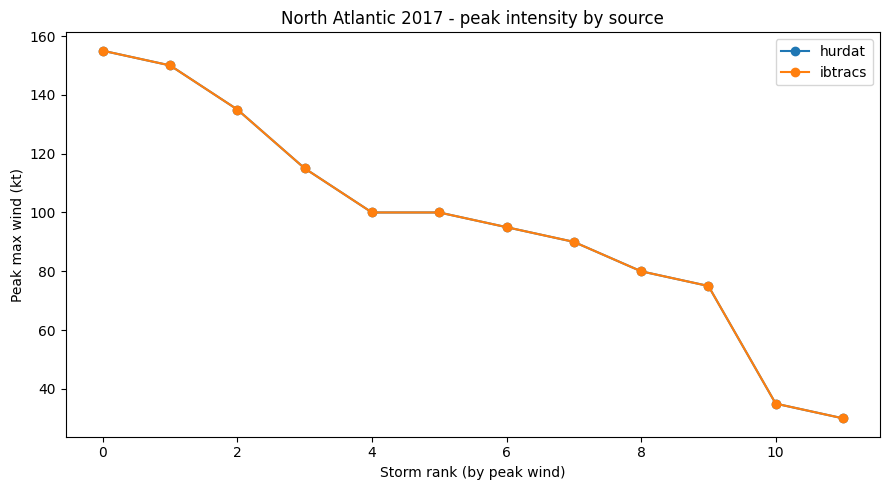

In [4]:
if by_source:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(9, 5))
    for src, fc in by_source.items():
        peak = fc.groupby('name')['vmax_kt'].max().sort_values(ascending=False)
        ax.plot(range(len(peak)), peak.values, 'o-', label=src)
    ax.set_xlabel('Storm rank (by peak wind)')
    ax.set_ylabel('Peak max wind (kt)')
    ax.set_title('North Atlantic 2017 - peak intensity by source')
    ax.legend()
    plt.tight_layout()
    plt.show()